# بررسی و کاوش داده‌ها

قبل از هر مدلی، اول باید خود داده رو بشناسم. داده مال ۷۶۸ بیمار زنه؛ هر کدوم ۸ ویژگی
پزشکی دارن و یه ستون Outcome که می‌گه طرف دیابت داشته (۱) یا نه (۰).

اینجا دنبال این چیزهام:

- ستون‌ها چی‌ان و بازه‌شون چنده
- مقادیر گمشده (که اینجا به‌شکل صفر قایم شدن)
- کلاس‌ها چقدر متوازن‌ان
- کدوم ویژگی‌ها به دیابت ربط دارن

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore') # این خروجی رو از ارور تمیز میکنه 

## خواندن داده‌ها

In [ ]:
df = pd.read_csv('../data/diabetes.csv')
print('shape:', df.shape)
df.head()

shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## آمار توصیفی

یه نگاه به آمار کلی. همین‌جا یه چیز مشکوک پیداست: کمینهٔ بعضی ستون‌ها مثل Glucose و
BMI صفره، که از نظر پزشکی ممکن نیست.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## مقادیر گمشده

ظاهراً nan نداریم، ولی این گول‌زننده‌ست. توی چند ستون عددِ صفر معنی نداره (کسی گلوکز
یا BMI صفر نداره)، پس این صفرها در واقع داده‌های گمشده‌ان.

بدترین حالت مال Insulin و SkinThickness‌ه که کلی صفر دارن.

In [ ]:
print('NaN per column:')
print(df.isnull().sum().to_string())

# ستون هایی که صفر تونشون به معنی nan هستش 
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print()
print('zeros (treated as missing):')
for col in zero_cols:
    n = (df[col] == 0).sum()
    print(f'  {col:14s} {n:3d}  ({n/len(df)*100:.1f}%)')

NaN per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0

zeros (treated as missing):
  Glucose          5  (0.7%)
  BloodPressure   35  (4.6%)
  SkinThickness  227  (29.6%)
  Insulin        374  (48.7%)
  BMI             11  (1.4%)


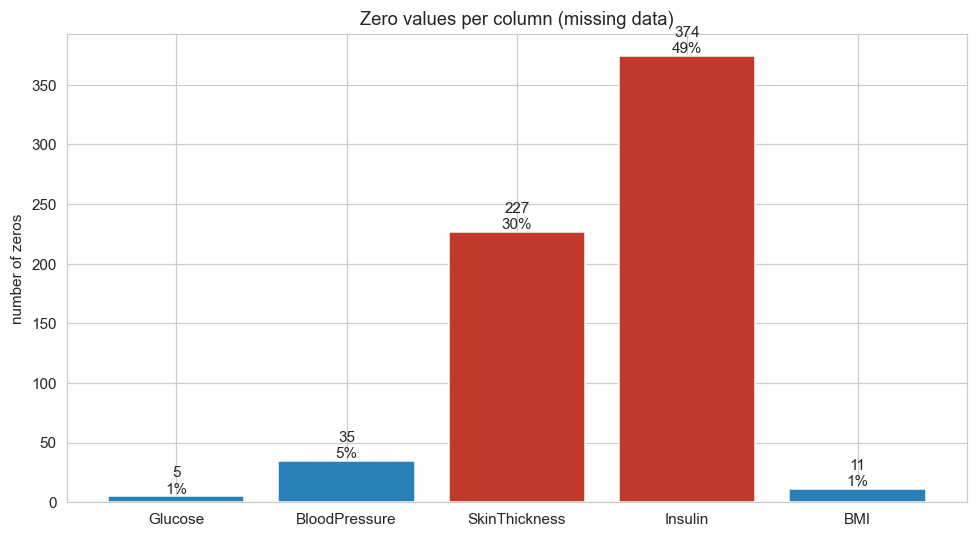

In [6]:
# نمودار میله‌ای تعداد صفرها در هر ستون
counts = [(df[c] == 0).sum() for c in zero_cols]
colors = ['#c0392b' if c > 100 else '#2980b9' for c in counts]   # ستون‌های پرمشکل را قرمز می‌کنم

plt.figure(figsize=(9, 5))
bars = plt.bar(zero_cols, counts, color=colors)
plt.ylabel('number of zeros')
plt.title('Zero values per column (missing data)')
for b, c in zip(bars, counts):
    plt.text(b.get_x() + b.get_width()/2, c, f'{c}\n{c/len(df)*100:.0f}%',
             ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../figures/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## توزیع ویژگی‌ها

شکل توزیع هر ویژگی رو با هیستوگرام نگاه می‌کنم.

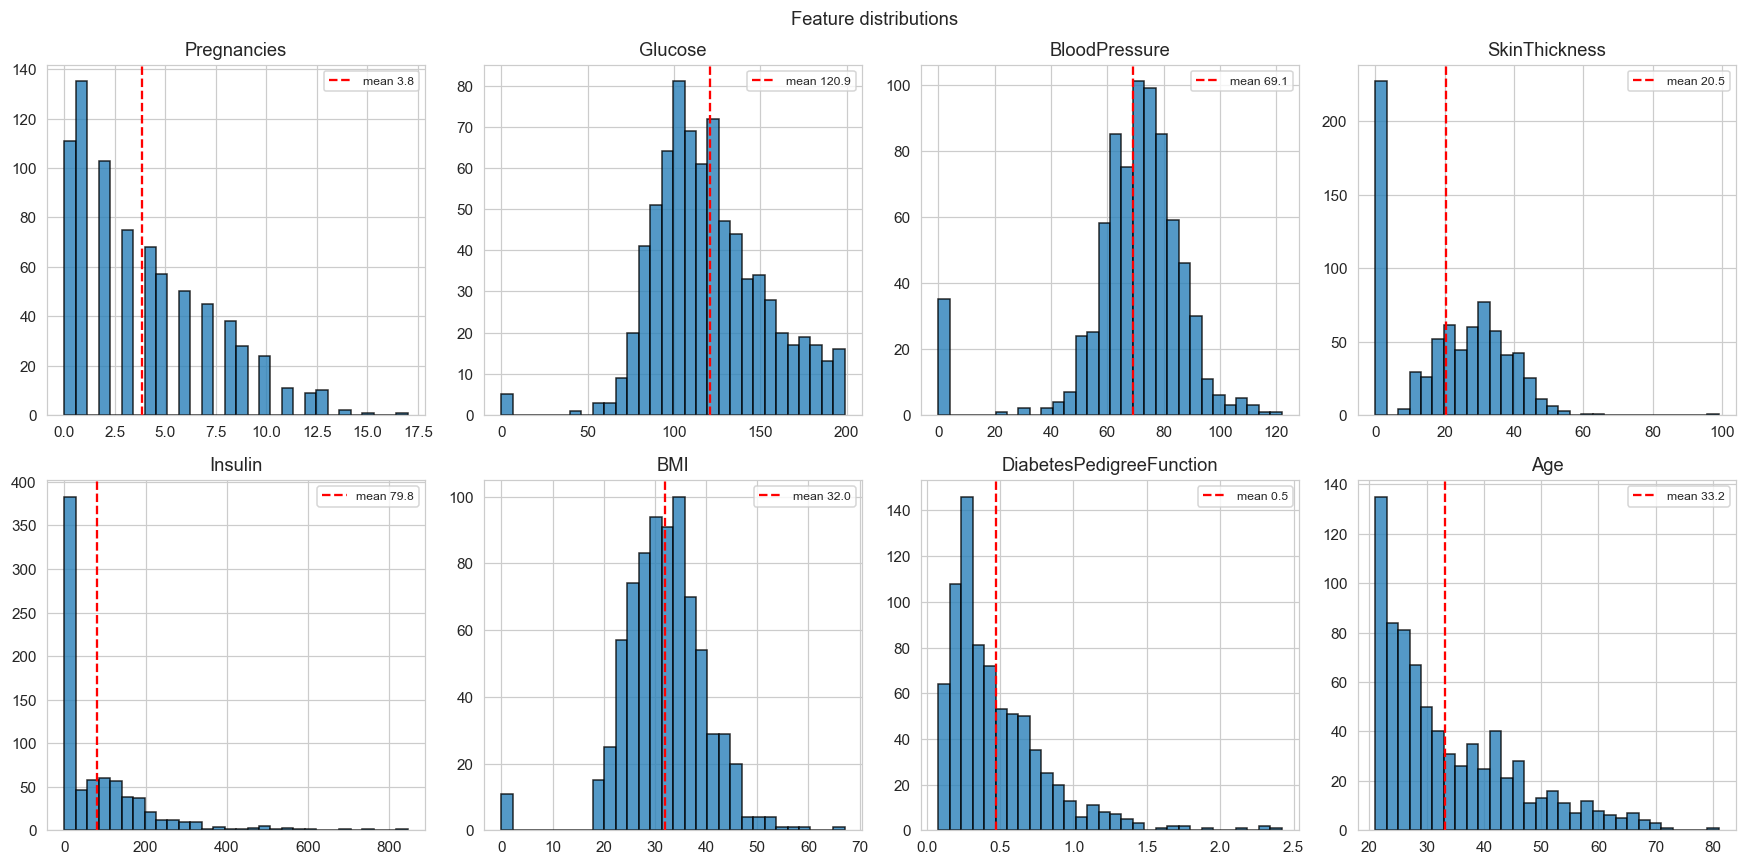

In [7]:
# هیستوگرام هر ویژگی به همراه خط میانگین
features = list(df.columns[:-1])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, features):
    ax.hist(df[col], bins=30, color='#2980b9', alpha=0.8, edgecolor='black')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'mean {df[col].mean():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle('Feature distributions')
plt.tight_layout()
plt.savefig('../figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## داده‌های پرت

با نمودار جعبه‌ای داده‌های پرت رو می‌بینم. دو ستون Insulin و DiabetesPedigreeFunction
از همه پرت‌تر‌ان.

به‌خاطر همین پرت‌ها، بعداً برای پر کردن گمشده‌ها میانه رو انتخاب می‌کنم نه میانگین.

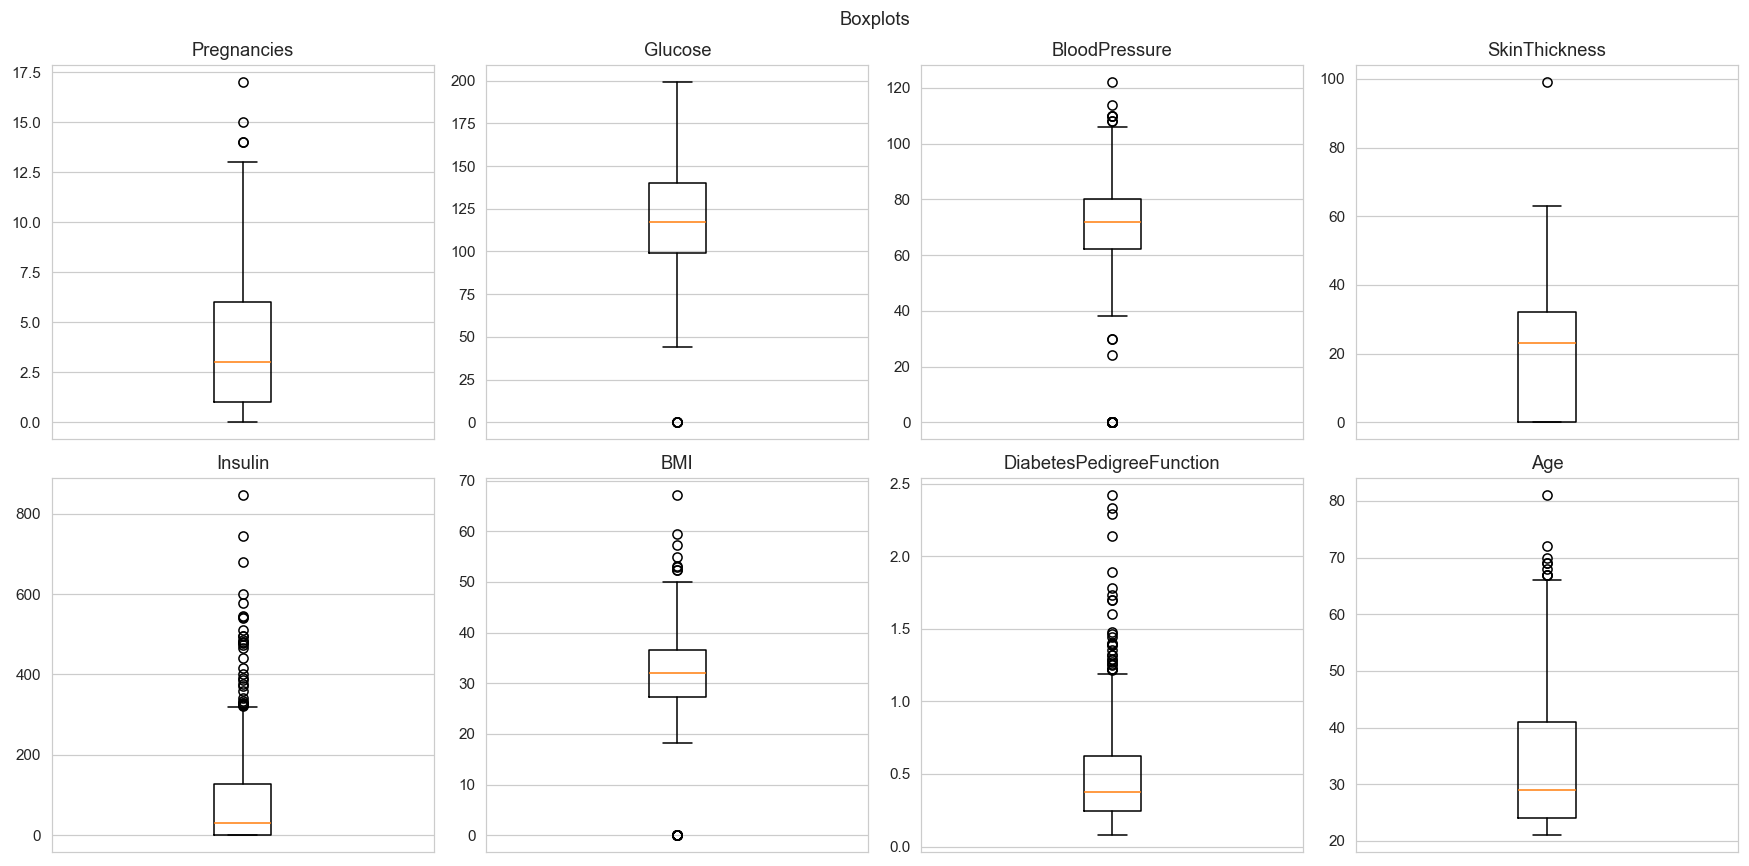

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, features):
    ax.boxplot(df[col])
    ax.set_title(col)
    ax.set_xticks([])
fig.suptitle('Boxplots')
plt.tight_layout()
plt.savefig('../figures/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## همبستگی‌ها

ماتریس همبستگی نشون می‌ده کدوم ویژگی‌ها با هم و با خروجی رابطه دارن. بیشتر از همه ستون
Outcome برام مهمه.

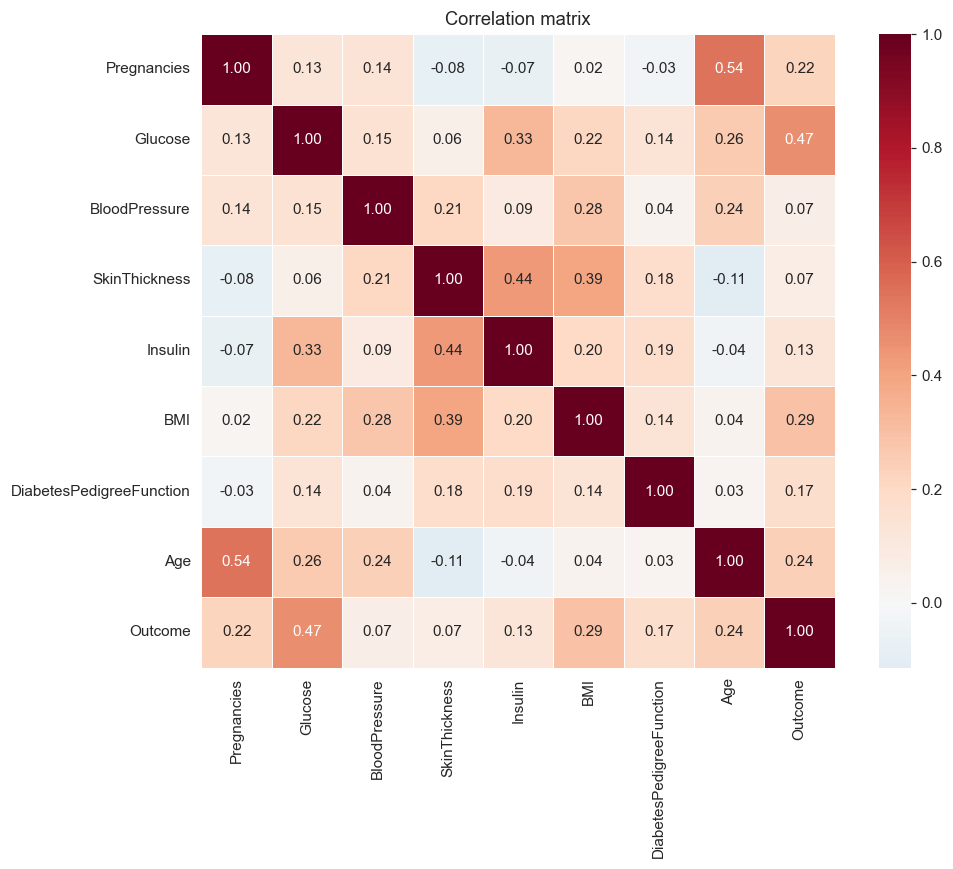

In [ ]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('../figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
target_corr = corr['Outcome'].drop('Outcome').sort_values(ascending=False)
print('correlation with Outcome:')
print(target_corr.round(3).to_string())

correlation with Outcome:
Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065


## توازن کلاس‌ها

تعداد سالم‌ها بیشتر از دیابتی‌هاست. این رو موقع انتخاب معیار ارزیابی حواسم هست.

In [ ]:
class_counts = df['Outcome'].value_counts()
n_neg, n_pos = int(class_counts.loc[0]), int(class_counts.loc[1])

print(f'no diabetes (0): {n_neg}  ({n_neg/len(df)*100:.1f}%)')
print(f'diabetes (1):    {n_pos}  ({n_pos/len(df)*100:.1f}%)')
print(f'ratio: {n_neg/n_pos:.2f} : 1')

no diabetes (0): 500  (65.1%)
diabetes (1):    268  (34.9%)
ratio: 1.87 : 1


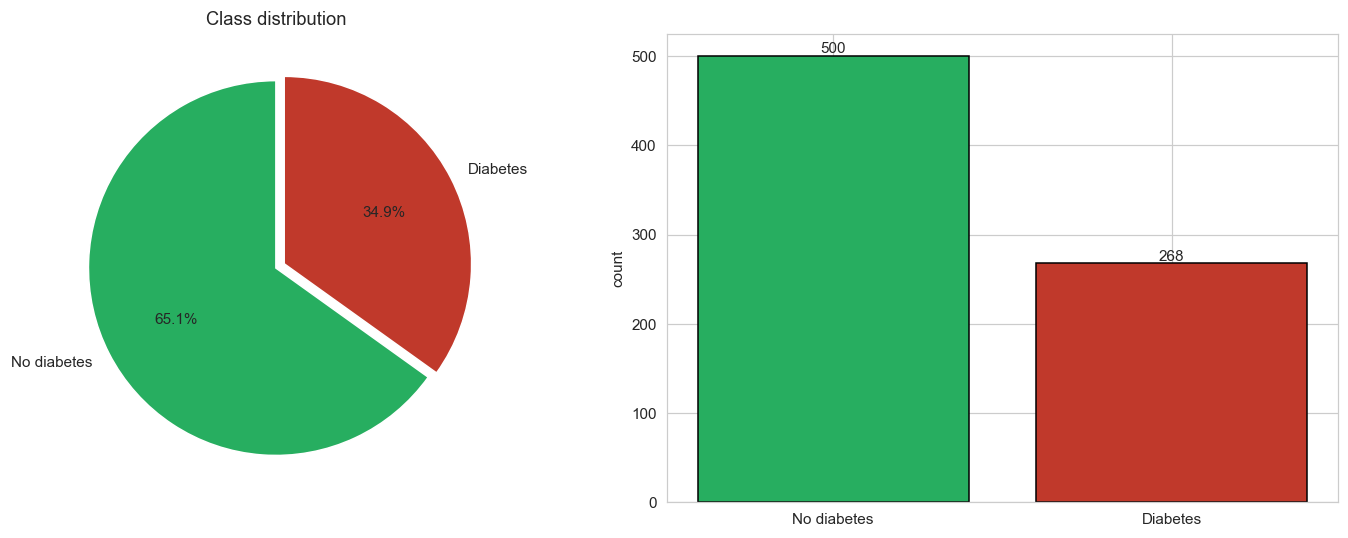

In [ ]:
# نمایش توازن کلاس‌ها با نمودار دایره‌ای و میله‌ای
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#27ae60', '#c0392b']
labels = ['No diabetes', 'Diabetes']

axes[0].pie([n_neg, n_pos], labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, explode=(0, 0.05))
axes[0].set_title('Class distribution')

bars = axes[1].bar(labels, [n_neg, n_pos], color=colors, edgecolor='black')
for b in bars:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height(), int(b.get_height()),
                 ha='center', va='bottom')
axes[1].set_ylabel('count')
plt.tight_layout()
plt.savefig('../figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## توزیع ویژگی‌ها به تفکیک کلاس

حالا توزیع هر ویژگی رو برای دو گروه (سالم و دیابتی) جدا می‌کشم تا ببینم کدوم بهتر دو
گروه رو از هم جدا می‌کنه. Glucose از همه واضح‌تره.

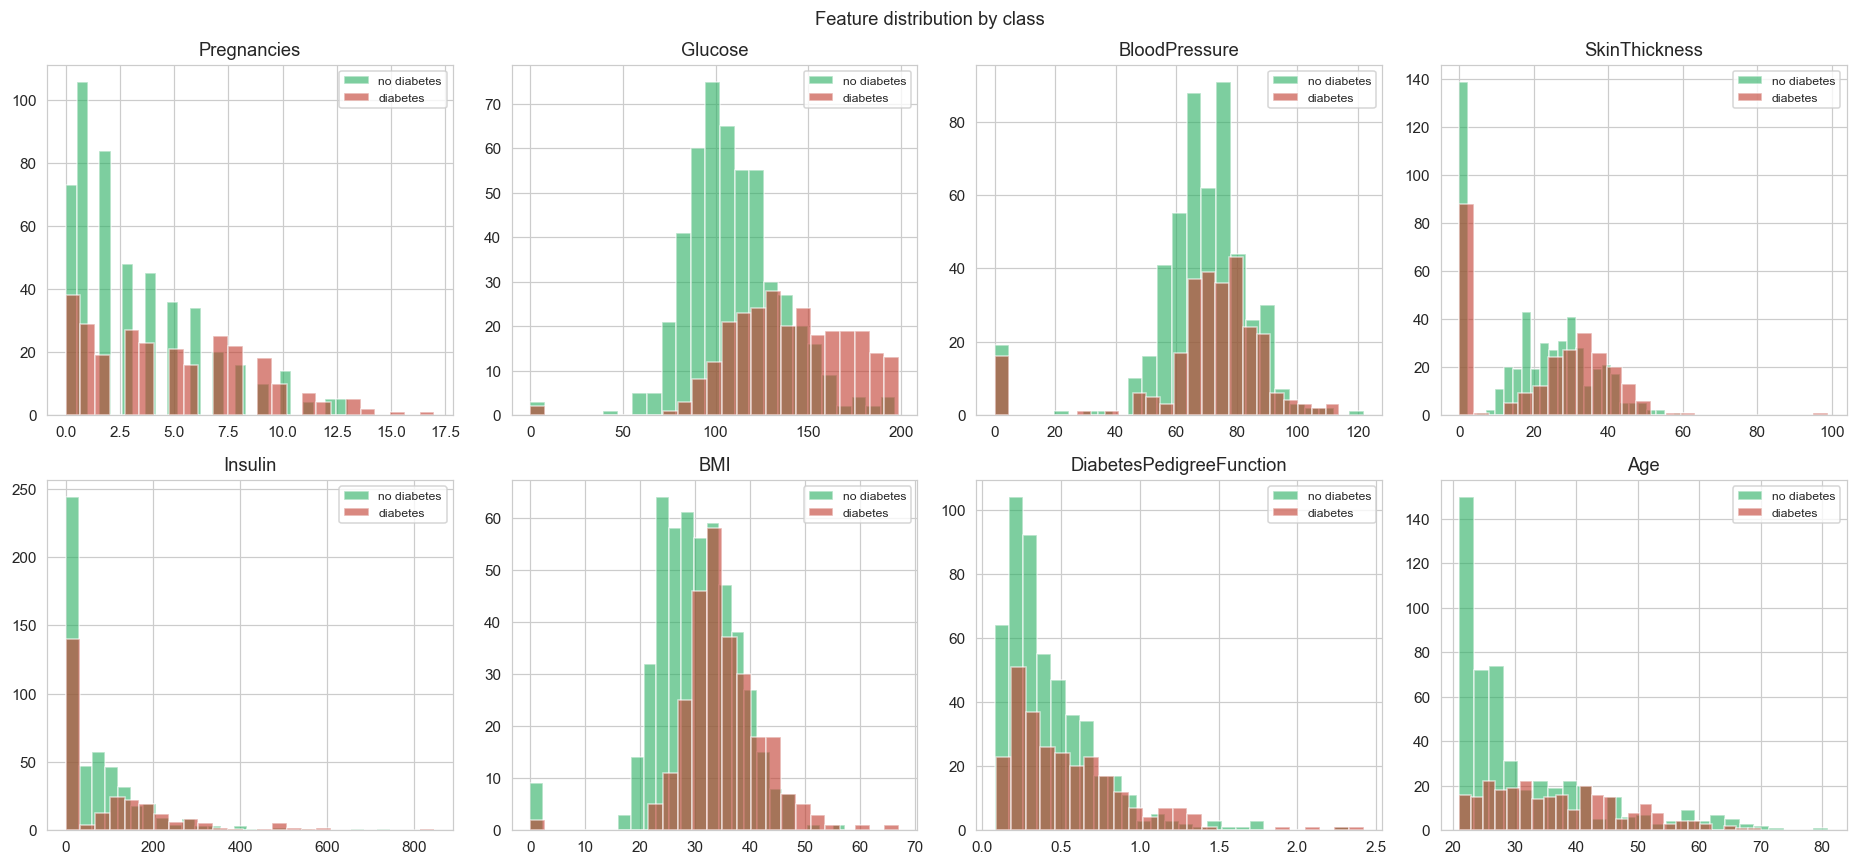

In [13]:
# مقایسهٔ هیستوگرام هر ویژگی برای دو کلاس
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
healthy = df[df['Outcome'] == 0]
diabetic = df[df['Outcome'] == 1]

for ax, col in zip(axes.flat, features):
    ax.hist(healthy[col], bins=25, alpha=0.6, label='no diabetes', color='#27ae60')
    ax.hist(diabetic[col], bins=25, alpha=0.6, label='diabetes', color='#c0392b')
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle('Feature distribution by class')
plt.tight_layout()
plt.savefig('../figures/features_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# میانگین هر ویژگی در دو کلاس و درصد اختلاف
by_class = df.groupby('Outcome').mean().T
by_class.columns = ['no diabetes', 'diabetes']
by_class['diff %'] = (by_class['diabetes'] - by_class['no diabetes']) / by_class['no diabetes'] * 100
by_class.round(2)

,no diabetes,diabetes,diff %
Pregnancies,3.30,4.87,47.53
Glucose,109.98,141.26,28.44
BloodPressure,68.18,70.82,3.87
SkinThickness,19.66,22.16,12.71
Insulin,68.79,100.34,45.85
BMI,30.30,35.14,15.97
DiabetesPedigreeFunction,0.43,0.55,28.10
Age,31.19,37.07,18.84


## رابطهٔ دوبه‌دوی ویژگی‌ها

نمودار جفتی برای چهار ویژگی‌ای که بیشترین ربط رو به خروجی دارن.

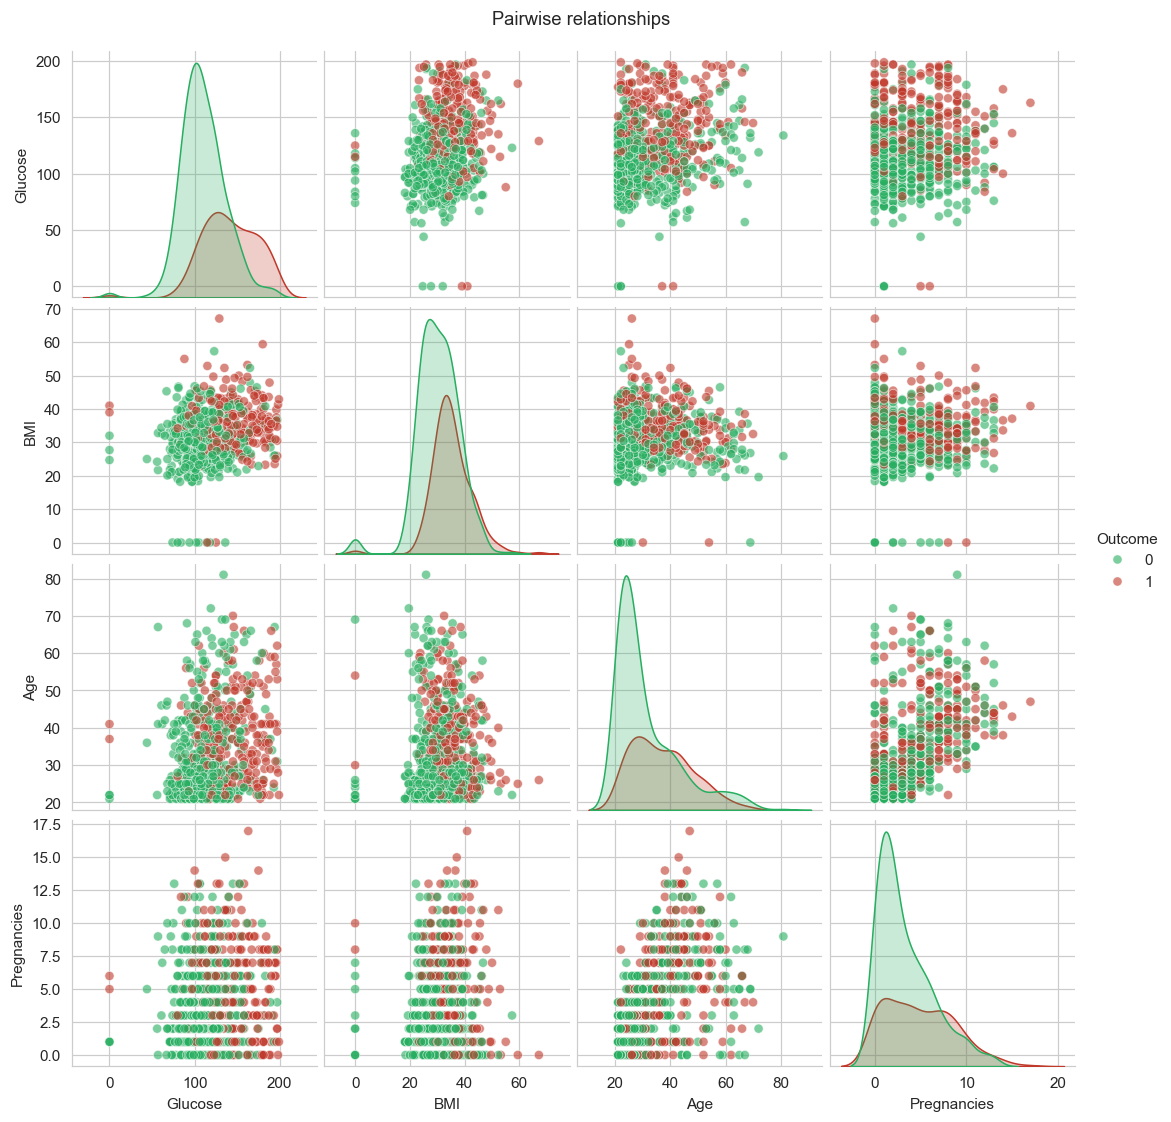

In [ ]:
key = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'Outcome']
g = sns.pairplot(df[key], hue='Outcome',
                 palette={0: '#27ae60', 1: '#c0392b'},
                 diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairwise relationships', y=1.02)
plt.savefig('../figures/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## جمع‌بندی این مرحله

سه چیز از این نوت‌بوک فهمیدم:

- **مقادیر گمشده:** بعضی صفرها در واقع گمشده‌ان، بیشتر توی Insulin و SkinThickness.
- **عدم توازن:** حدود ۶۵٪ سالم و ۳۵٪ دیابتی، پس فقط دقت کافی نیست.
- **ویژگی مهم:** گلوکز (Glucose) بیشترین ربط رو به دیابت داره، بعد BMI و سن.

این‌ها تصمیم‌های نوت‌بوک بعدی رو مشخص می‌کنن.